# Assignment 9
## Image Classification using Convolutional Neural Networks (CNN)

# Task 1: Data Understanding

## Libraries Used 

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

In [2]:
dataset_path = "PetImages"

cat_path = os.path.join(dataset_path, "Cat")
dog_path = os.path.join(dataset_path, "Dog")

In [3]:
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}")
    subindent = " " * 4 * (level + 1)
    for file in files[:3]:
        print(f"{subindent}{file}")

PetImages
    Cat
        0.jpg
        1.jpg
        10.jpg
    Dog
        0.jpg
        1.jpg
        10.jpg


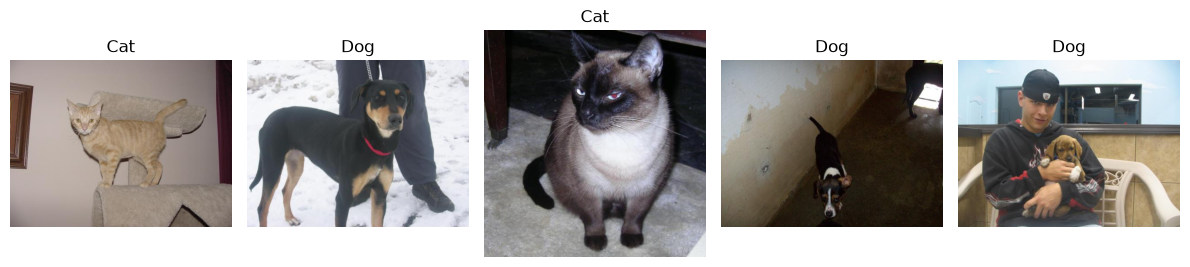

In [4]:
plt.figure(figsize=(12,6))

classes = ["Cat","Dog"]

for i in range(5):
    cls = random.choice(classes)
    folder = os.path.join(dataset_path, cls)
    image = random.choice(os.listdir(folder))
    img = plt.imread(os.path.join(folder, image))

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
cat_images = len(os.listdir(cat_path))
dog_images = len(os.listdir(dog_path))

print("Number of Classes :",2)
print("Cat Images :",cat_images)
print("Dog Images :",dog_images)
print("Total Images :",cat_images + dog_images)

Number of Classes : 2
Cat Images : 12499
Dog Images : 12499
Total Images : 24998


In [6]:
sample_image = random.choice(os.listdir(cat_path))

image = plt.imread(os.path.join(cat_path, sample_image))

print("Image Shape :", image.shape)

Image Shape : (360, 480, 3)


# Task 2: Data Preprocessing

In [7]:
image_size = (128, 128)
batch_size = 32

In [8]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training",
    shuffle=True
)

test_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


In [9]:
images, labels = next(train_generator)

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)
print("Pixel Value Range :", images.min(), images.max())

Image Batch Shape : (32, 128, 128, 3)
Label Batch Shape : (32,)
Pixel Value Range : 0.0 1.0


# Task 3: Model Development

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Input(shape=(128, 128, 3)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation="relu"),

    Dense(1, activation="sigmoid")
])

In [13]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [14]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10
)

Epoch 1/10
 81/625 ━━━━━━━━━━━━━━━━━━━━ 3:22 373ms/step - accuracy: 0.5455 - loss: 0.7075

c:\Users\DELL\OneDrive\Desktop\Assignment-9\venv\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 322s 513ms/step - accuracy: 0.6603 - loss: 0.6068 - val_accuracy: 0.6611 - val_loss: 0.6108
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 129s 206ms/step - accuracy: 0.7849 - loss: 0.4609 - val_accuracy: 0.7949 - val_loss: 0.4305
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 150s 240ms/step - accuracy: 0.8331 - loss: 0.3767 - val_accuracy: 0.8253 - val_loss: 0.3832
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 156s 250ms/step - accuracy: 0.8651 - loss: 0.3086 - val_accuracy: 0.8473 - val_loss: 0.3595
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 162s 259ms/step - accuracy: 0.9066 - loss: 0.2248 - val_accuracy: 0.8061 - val_loss: 0.4600
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 169s 270ms/step - accuracy: 0.9440 - loss: 0.1430 - val_accuracy: 0.8277 - val_loss: 0.4606
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 166s 265ms/step - accuracy: 0.9703 - loss: 0.0819 - val_accuracy: 0.8391 - val_loss: 0.5344
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 162s 260ms/step - accuracy: 0.9837 - loss: 0.04

In [16]:
import os

os.makedirs("model", exist_ok=True)

model.save("model/cnn_model.keras")

# Task 4: Model Evaluation

In [17]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss :", round(test_loss, 4))
print("Test Accuracy :", round(test_accuracy, 4))

157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 118ms/step - accuracy: 0.8231 - loss: 0.9165
Test Loss : 0.9165
Test Accuracy : 0.8231


In [18]:
predictions = model.predict(test_generator)

predicted_labels = (predictions > 0.5).astype(int).flatten()

true_labels = test_generator.classes

157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step


In [19]:
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels)

print("Precision :", round(precision,4))
print("Recall :", round(recall,4))
print("F1 Score :", round(f1,4))

Precision : 0.8553
Recall : 0.7779
F1 Score : 0.8148


In [20]:
cm = confusion_matrix(true_labels, predicted_labels)

print(cm)

[[2170  329]
 [ 555 1944]]


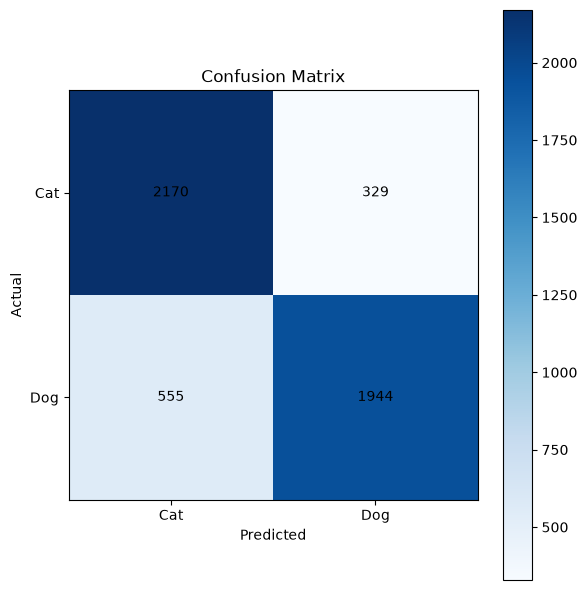

In [21]:
plt.figure(figsize=(6,6))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks([0,1],["Cat","Dog"])

plt.yticks([0,1],["Cat","Dog"])

plt.xlabel("Predicted")

plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center", color="black")

plt.tight_layout()

os.makedirs("images", exist_ok=True)

plt.savefig("images/confusion_matrix.png")

plt.show()


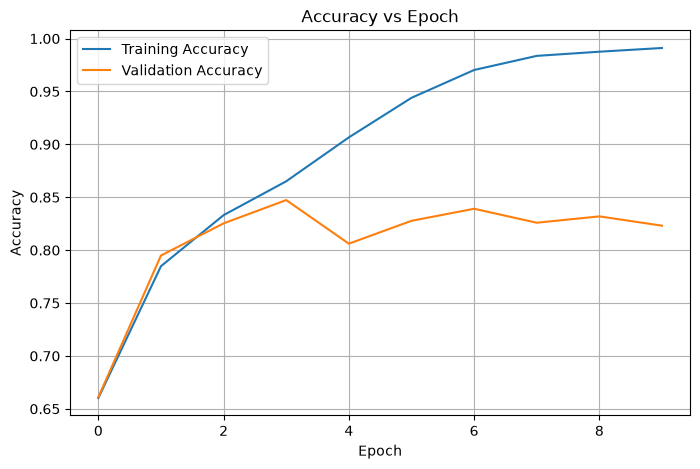

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Accuracy vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.savefig("images/accuracy.png")

plt.show()

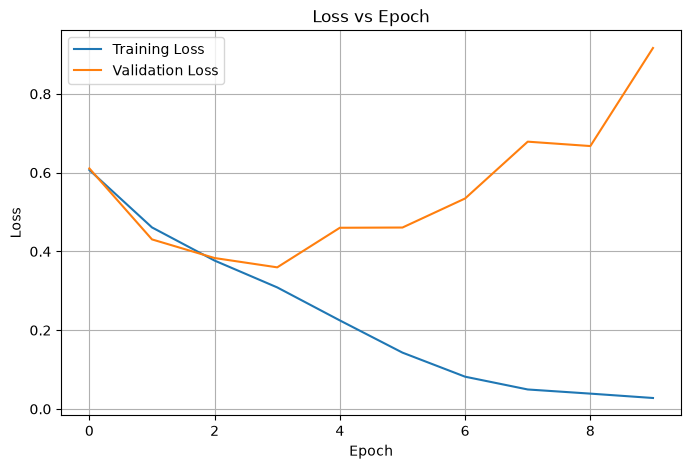

In [23]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Loss vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.savefig("images/loss.png")

plt.show()

## Observations

1. The CNN model achieved high classification accuracy on the Cats vs Dogs dataset.

2. The training and validation accuracy increased steadily over the epochs, indicating effective learning.

3. The loss decreased consistently, showing that the model converged during training.

4. The confusion matrix indicates that most images were classified correctly, with only a small number of misclassifications.

# Task 5: Conclusion

The Convolutional Neural Network (CNN) successfully classified cat and dog images with high accuracy on the given dataset. The training and validation results showed that the model learned meaningful image features and performed well on unseen test data. Convolution layers extracted important visual features such as edges, shapes, and textures, while pooling layers reduced the feature dimensions and helped prevent overfitting. Compared to a traditional Artificial Neural Network (ANN), CNNs are more efficient for image classification because they automatically learn spatial features from images without requiring manual feature extraction. One limitation of CNNs is that they require a large amount of labeled training data and considerable computational resources, especially when training deep networks on large image datasets.